**Author:** Tianqi Shen & GPT-4o

**Date:** 26 May 2026

# Empirical Evidence for Muon as an Early Exploration Optimizer
## 2-Layer Neural Network Case

To examine when Muon performs well, we consider a toy model that uses a two-layer neural network to recognize handwritten digits on MNIST.

In [1]:
%matplotlib inline
#import matplotlib_inline   # setup output image format, do not use 'svg' if need 'pdf' output
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import matplotlib
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    # This seed is derived from the DataLoader's generator (each worker is different).
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=3)

### Load MNIST dataset and perform data preprocessing

In [2]:
data_generator = torch.Generator()
data_generator.manual_seed(42)

# MNIST: 28x28 -> flatten to 784; normalize to standard MNIST mean/std
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

data_dir = "./data"
train_ds = datasets.MNIST(root=data_dir, train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root=data_dir, train=False, download=True, transform=tfm)

batch_size = 512  # create different loaders for different optimizers
train_loader1 = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, 
                           worker_init_fn=seed_worker, generator=data_generator,)
test_loader1 = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=data_generator,)
train_loader2 = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, 
                           worker_init_fn=seed_worker, generator=data_generator,)
test_loader2 = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=data_generator,)
train_loader3 = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, 
                           worker_init_fn=seed_worker, generator=data_generator,)
test_loader3 = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=data_generator,)
train_loader4 = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, 
                           worker_init_fn=seed_worker, generator=data_generator,)
test_loader4 = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=data_generator,)
train_loader5 = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, 
                           worker_init_fn=seed_worker, generator=data_generator,)
test_loader5 = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=data_generator,)

print(f"training dataset length: {len(train_ds)}; testing dataset length: {len(test_ds)}")
print(f"train_loader length: {len(train_loader1)}; test_loader length: {len(test_loader1)}")

training dataset length: 60000; testing dataset length: 10000
train_loader length: 118; test_loader length: 20


### Build two-layer neural network

In [3]:
class TwoLayerMLP(nn.Module):
    def __init__(self, in_dim=28*28, hidden_dim=256, num_classes=10, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout) if dropout and dropout > 0 else nn.Identity()

    def forward(self, x):
        # x: (B, 1, 28, 28)
        x = x.view(x.size(0), -1)          # -> (B, 784)
        x = F.relu(self.fc1(x))            # -> (B, H)
        x = self.dropout(x)
        x = self.fc2(x)                    # -> (B, 10) logits
        return x

set_seed(42)  # build different models for different optimizers
model1 = TwoLayerMLP(hidden_dim=256, dropout=0.1).to(device)
model1_params = {k: v.detach().clone() for k, v in model1.state_dict().items()}
model2 = TwoLayerMLP(hidden_dim=256, dropout=0.1).to(device)
model2.load_state_dict(model1_params)
model3 = TwoLayerMLP(hidden_dim=256, dropout=0.1).to(device)
model3.load_state_dict(model1_params)
model4 = TwoLayerMLP(hidden_dim=256, dropout=0.1).to(device)
model4.load_state_dict(model1_params)
model5 = TwoLayerMLP(hidden_dim=256, dropout=0.1).to(device)
model5.load_state_dict(model1_params)
sum(p.numel() for p in model1.parameters())

203530

### Functions for training and evaluation

In [4]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y, reduction="sum")
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total += y.numel()
    return total_loss / total, total_correct / total

def train(model, train_loader, test_loader, optimizer, epochs=5, log_every=100, eval_every=1,):
    history = {
        "train_step": [],
        "train_loss": [],
        "test_step": [],
        "test_loss": [],
        "test_acc": [],
    }

    global_step = 0
    running_loss = 0.0
    running_count = 0

    for epoch in range(1, epochs + 1):
        model.train()

        for i, (x, y) in enumerate(train_loader, start=1):
            global_step += 1
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            # record per-step train loss
            history["train_step"].append(global_step)
            history["train_loss"].append(float(loss.item()))

            # for printing a smoother number
            running_loss += float(loss.item())
            running_count += 1

            if log_every and (i % log_every == 0):
                avg = running_loss / max(1, running_count)
                test_loss, test_acc = evaluate(model, test_loader)
                print(f"epoch {epoch:02d} | iter {i:04d}/{len(train_loader)} "
                      f"| step {global_step:06d} | train_loss(avg) {avg:.4f} "
                      f"| test_loss {test_loss:.4f} | test_acc {test_acc*100:.2f}%")
                running_loss = 0.0
                running_count = 0

            # periodic evaluation on test set (x-axis is steps)
            if eval_every and (global_step % eval_every == 0):
                test_loss, test_acc = evaluate(model, test_loader)
                history["test_step"].append(global_step)
                history["test_loss"].append(float(test_loss))
                history["test_acc"].append(float(test_acc))

        # end-of-epoch eval (optional, but usually useful)
        test_loss, test_acc = evaluate(model, test_loader)
        history["test_step"].append(global_step)
        history["test_loss"].append(float(test_loss))
        history["test_acc"].append(float(test_acc))
        print(f"[EPOCH END] epoch {epoch:02d} | step {global_step:06d} "
              f"| test_loss {test_loss:.4f} | test_acc {test_acc*100:.2f}%")

    return history

### Function for $msign$ operator

In [5]:
@torch.no_grad()
def msign(t: torch.Tensor, eps: float = 0.0):
    """
    msign(t) = U sign(S) Vh, where t = U S Vh (SVD, real tensors assumed).

    Conventions:
    - sign(s) = 1 if s > eps else 0   (for singular values s >= 0)
    - 2D: returns U @ Diag(sign(S)) @ Vh (a partial isometry / polar-like factor)
    - 1D: returns t / ||t||_2 if ||t||_2 > eps else 0
    """
    if t.ndim == 2:
        U, S, Vh = torch.linalg.svd(t, full_matrices=False)  # U:(n1,r), S:(r,), Vh:(r,n2)
        mask = (S > eps).to(dtype=t.dtype)                   # (r,)
        # U @ Diag(mask) is equivalent to scaling columns of U by mask
        return (U * mask) @ Vh

    elif t.ndim == 1:
        norm_t = torch.linalg.norm(t)
        if norm_t <= eps:
            return torch.zeros_like(t)
        return t / norm_t

    else:
        raise ValueError(f"msign only supports 1D or 2D tensors, got shape {tuple(t.shape)}")
        
test1 = torch.tensor([[1.0, 2.0], [2.0, 1.0]])
U1, S1, Vh1 = torch.linalg.svd(test1, full_matrices=False)
print("polar factor of test1:\n", U1 @ Vh1)
print("msign of test1:\n", msign(test1))
# test2 = torch.outer(torch.torch.tensor([1.0, 2.0, 3.0]), torch.tensor([4.0, 5.0]))
# U2, S2, Vh2 = torch.linalg.svd(test2, full_matrices=False)
# print("polar factor of test2:\n", U2 @ Vh2)
# print("msign of test2:\n", msign(test2))
# test3 = torch.tensor([1.0, 1.0]).view(-1, 1)
# U3, S3, Vh3 = torch.linalg.svd(test3, full_matrices=False)
# print("polar factor of test3:\n", U3 @ Vh3)
# print("msign of test3:\n", msign(test3))
# test4 = torch.tensor([6.6]).view(-1, 1)
# U4, S4, Vh4 = torch.linalg.svd(test4, full_matrices=False)
# print("polar factor of test4:\n", U4 @ Vh4)
# print("msign of test4:\n", msign(test4))
test5 = torch.zeros(4).view(-1, 1)
U5, S5, Vh5 = torch.linalg.svd(test5, full_matrices=False)
print("polar factor of test5:\n", U5 @ Vh5)
print("msign of test5:\n", msign(test5))

polar factor of test1:
 tensor([[ 5.9261e-08,  1.0000e+00],
        [ 1.0000e+00, -2.5033e-08]])
msign of test1:
 tensor([[ 5.9261e-08,  1.0000e+00],
        [ 1.0000e+00, -2.5033e-08]])
polar factor of test5:
 tensor([[1.],
        [0.],
        [0.],
        [0.]])
msign of test5:
 tensor([[0.],
        [0.],
        [0.],
        [0.]])


### Load hyper-parameters and build template for optimizers

In [6]:
class BaseOpt:
    def __init__(self, params):
        self.params = [p for p in params if p.requires_grad]

    @torch.no_grad()
    def zero_grad(self, set_to_none: bool = True):
        for p in self.params:
            if p.grad is None:
                continue
            if set_to_none:
                p.grad = None
            else:
                p.grad.zero_()
        
class Args:
    epochs = 5
    lr_m_gd = 0.01  # a bit too high if using momentum-gd as a late-optimizer, set lr=0.01 manually in hybrid case
    lr_adam = 0.001  # a bit too high if using adam as a late-optimizer, set lr=0.001 manually in hybrid case
    lr_muon = 0.1  #  muon deserves high lr (e.g. 0.1) as an early-optimizer
    muon_momentum_xi = 0.9
    m_gd_momentum_xi = 0.9
    adam_beta1 = 0.9
    adam_beta2 = 0.999
    adam_eps = 1e-8
    switch_muon_to_m_gd = 40  # int: after this step, use momentum-GD
    switch_muon_to_adam = 40  # int: after this step, use Adam
    log_every = 100
    eval_every = 1  # set 10 or higher to debug
args = Args()

steps_per_epoch = len(train_loader1)
steps_total = args.epochs * steps_per_epoch
print("total step number: ", steps_total)
assert args.switch_muon_to_m_gd < steps_total and args.switch_muon_to_adam < steps_total

total step number:  590


### Functional Helpers for Optimization (“pure” setting)
- Simulate Muon and baseline optimizers (momentum-GD or Adam) using a single optimizer throughout (*func:* `simulate_pure`). Define the gradient at iteration $t$ as $G_t := \nabla_X h \left( a_{t-1},b_{t-1} \right)$
 - Gradient descent with momentum (momentum-GD):
   $$
   M_t \gets G_t + \xi M_{t-1}, \qquad X_{t+1} \gets X_t - \eta^{\rm GD}\, M_t.
   $$
 - Adam (all operations are element-wise):
   $$
   M_t \gets \beta_1 M_{t-1} + (1 - \beta_1) G_t,
   \\
   V_t \gets \beta_2 V_{t-1} + (1 - \beta_2) \left(G_t \odot G_t\right),
   \\
   \hat{M}_t \gets \frac{M_t}{1 - \beta_1^t}, 
   \qquad 
   \hat{V}_t \gets \frac{V_t}{1 - \beta_2^t},
   \qquad
   X_{t+1} \gets X_t - \eta^{\rm Adam}\, \frac{\hat{M}_t}{\sqrt{\hat{V}_t} + \epsilon}.
   $$
 - Muon:
   $$
   M_t \gets G_t + \xi M_{t-1}, \qquad X_{t+1} \gets X_t - \eta^{\rm Muon}\, \mathtt{msign}(M_t).
   $$

In [7]:
class MomentumGD(BaseOpt):
    def __init__(self, params, lr=1e-2, momentum_xi=0.9):
        super().__init__(params)
        self.lr = lr
        self.xi = momentum_xi
        self.state = {id(p): torch.zeros_like(p) for p in self.params}  # velocity buffer

    @torch.no_grad()
    def step(self):
        for p in self.params:
            g = p.grad
            if g is None:
                continue
            v = self.state[id(p)]
            v.mul_(self.xi).add_(g)  # v = xi*v + g
            p.add_(v, alpha=-self.lr)  # p = p - lr*v

class Adam(BaseOpt):
    def __init__(self, params, lr=1e-2, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(params)
        self.lr = lr
        self.b1 = beta1
        self.b2 = beta2
        self.eps = eps
        self.t = 0
        self.m = {id(p): torch.zeros_like(p) for p in self.params}
        self.v = {id(p): torch.zeros_like(p) for p in self.params}

    @torch.no_grad()
    def step(self):
        self.t += 1
        b1, b2 = self.b1, self.b2
        for p in self.params:
            g = p.grad
            if g is None:
                continue
            m = self.m[id(p)]
            v = self.v[id(p)]
            m.mul_(b1).add_(g, alpha=1 - b1)
            v.mul_(b2).addcmul_(g, g, value=1 - b2)

            m_hat = m / (1 - b1 ** self.t)
            v_hat = v / (1 - b2 ** self.t)
            p.addcdiv_(m_hat, (v_hat.sqrt().add_(self.eps)), value=-self.lr)

class Muon(BaseOpt):
    def __init__(self, params, lr=1e-2, momentum_xi=0.9):
        super().__init__(params)
        self.lr = lr
        self.xi = momentum_xi
        self.M = {id(p): torch.zeros_like(p) for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            g = p.grad
            if g is None:
                continue
            M = self.M[id(p)]
            M.mul_(self.xi).add_(g)  # M = xi*M + g
            q = msign(M)
            p.add_(q, alpha=-self.lr)

### Run Optimization (“pure” setting)

In [8]:
print("-------- Momentum-GD update (heavy-ball) --------")
set_seed(42)
model1.load_state_dict(model1_params)
opt1 = MomentumGD(model1.parameters(), lr=args.lr_m_gd, momentum_xi=args.m_gd_momentum_xi)
history1 = train(model1, train_loader1, test_loader1, opt1, 
                 epochs=args.epochs, log_every=args.log_every, eval_every=args.eval_every)

print("-------- Adam update --------")
set_seed(42)
model2.load_state_dict(model1_params)
opt2 = Adam(model2.parameters(), lr=args.lr_adam, beta1=args.adam_beta1, beta2=args.adam_beta2, eps=args.adam_eps)
history2 = train(model2, train_loader2, test_loader2, opt2,  # this lr doesn't seem to be optimal for Adam
                 epochs=args.epochs, log_every=args.log_every, eval_every=args.eval_every)

print("-------- Muon update --------")
set_seed(42)
model3.load_state_dict(model1_params)
opt3 = Muon(model3.parameters(), lr=args.lr_muon, momentum_xi=args.muon_momentum_xi)
history3 = train(model3, train_loader3, test_loader3, opt3,  # this lr also makes Muon overfitting?
                 epochs=args.epochs, log_every=args.log_every, eval_every=args.eval_every)

-------- Momentum-GD update (heavy-ball) --------
epoch 01 | iter 0100/118 | step 000100 | train_loss(avg) 0.6789 | test_loss 0.3193 | test_acc 90.71%
[EPOCH END] epoch 01 | step 000118 | test_loss 0.3018 | test_acc 91.25%
epoch 02 | iter 0100/118 | step 000218 | train_loss(avg) 0.2909 | test_loss 0.2519 | test_acc 92.83%
[EPOCH END] epoch 02 | step 000236 | test_loss 0.2452 | test_acc 93.01%
epoch 03 | iter 0100/118 | step 000336 | train_loss(avg) 0.2403 | test_loss 0.2135 | test_acc 93.77%
[EPOCH END] epoch 03 | step 000354 | test_loss 0.2073 | test_acc 93.97%
epoch 04 | iter 0100/118 | step 000454 | train_loss(avg) 0.2021 | test_loss 0.1823 | test_acc 94.79%
[EPOCH END] epoch 04 | step 000472 | test_loss 0.1778 | test_acc 94.83%
epoch 05 | iter 0100/118 | step 000572 | train_loss(avg) 0.1740 | test_loss 0.1617 | test_acc 95.34%
[EPOCH END] epoch 05 | step 000590 | test_loss 0.1577 | test_acc 95.36%
-------- Adam update --------
epoch 01 | iter 0100/118 | step 000100 | train_loss(avg

### Plot Results (“pure” setting)

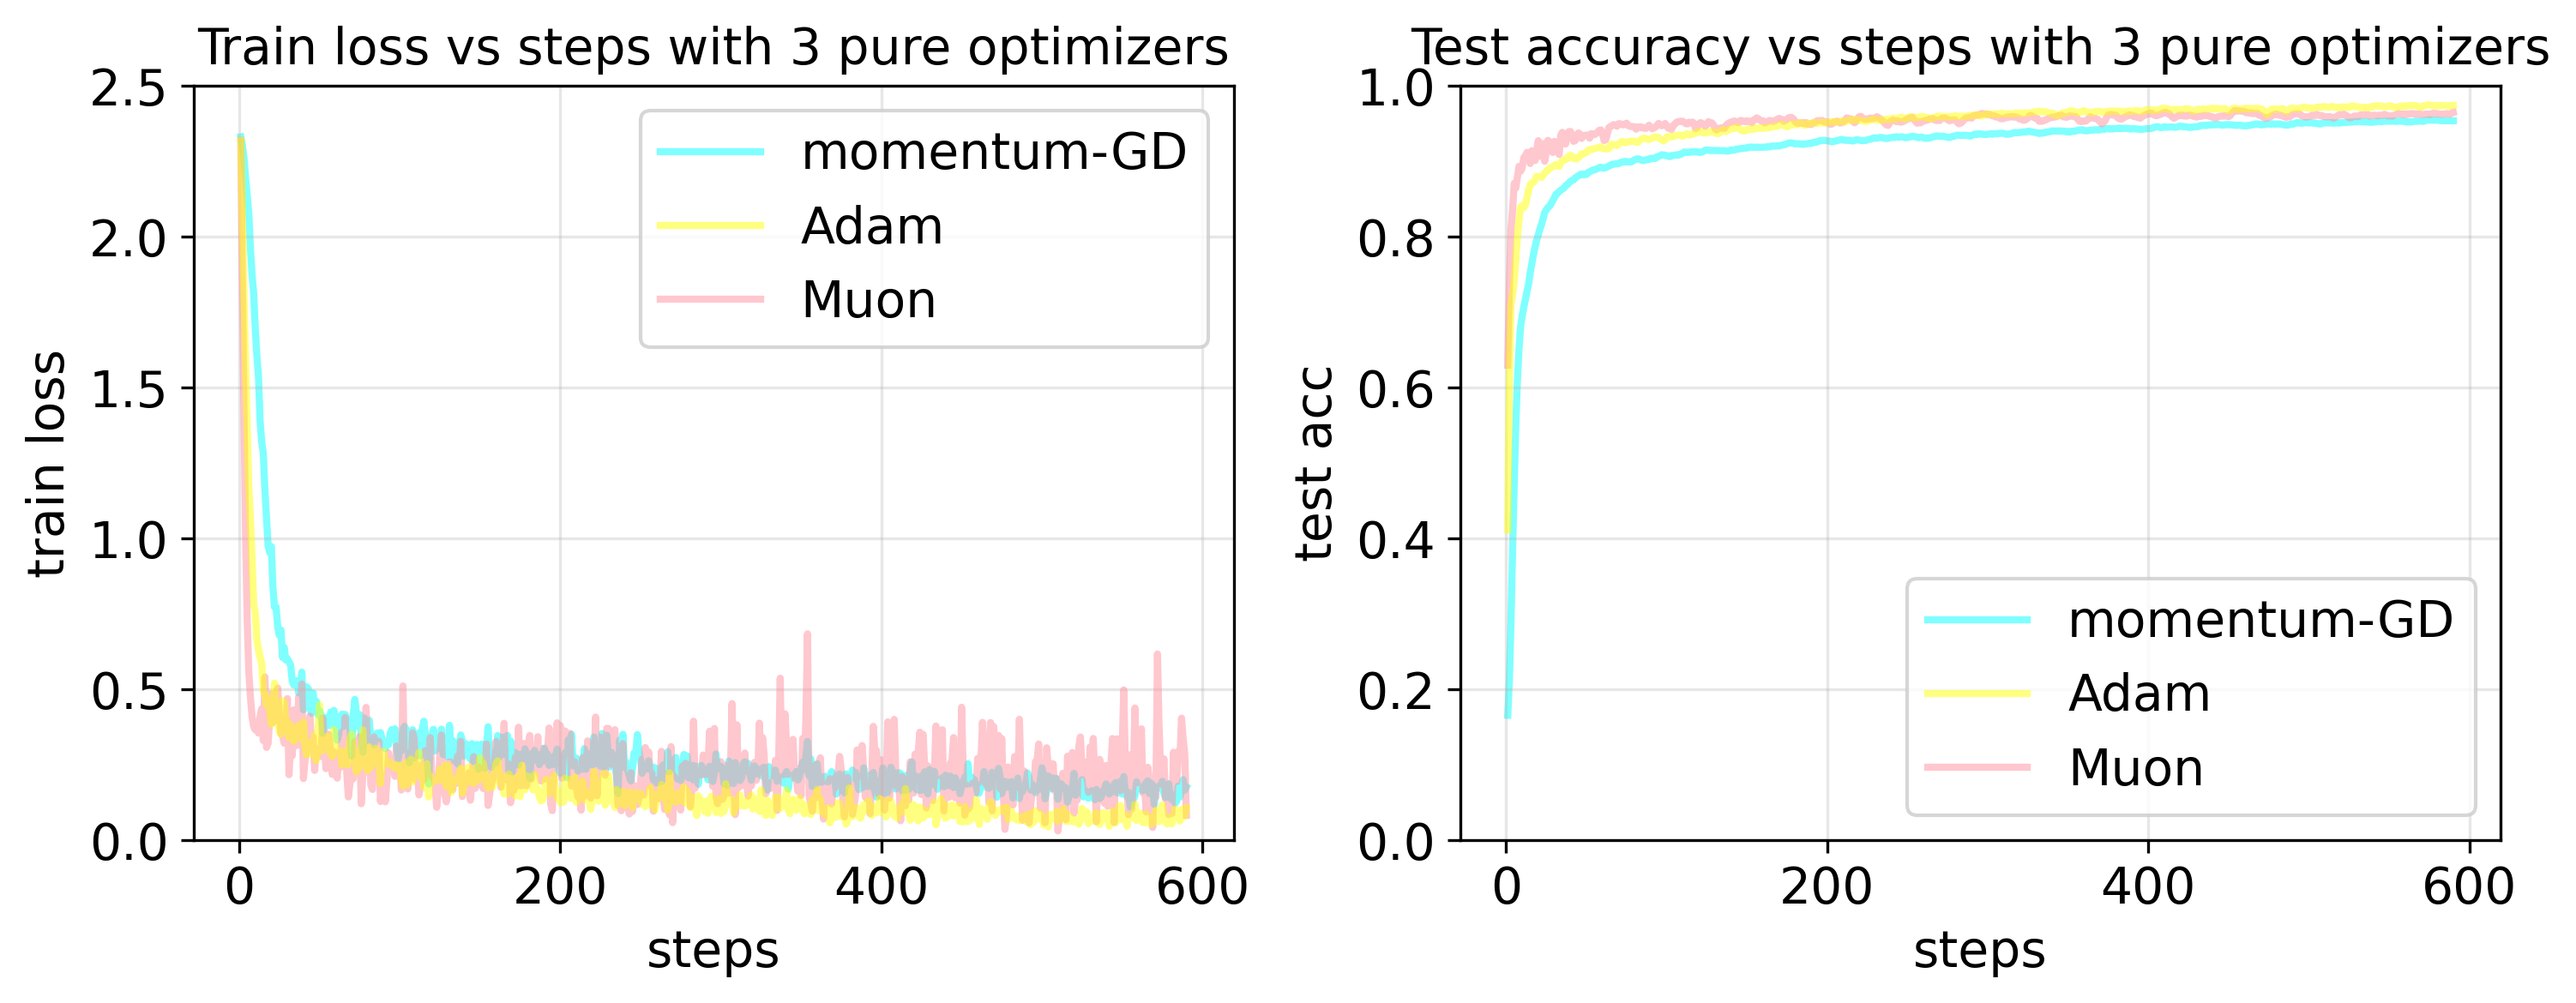

Saved figure to: two_layer_neural_network_case_pure.pdf


In [9]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw=dict(width_ratios=[1.0, 1.0]))

# left: train loss vs steps, we find muon converges the fastest
ax0.plot(history1["train_step"], history1["train_loss"], 
         linewidth=2.0, color="#00ffff", alpha=0.5, label="momentum-GD", zorder=1)
ax0.plot(history2["train_step"], history2["train_loss"], 
         linewidth=2.0, color="#ffff00", alpha=0.5, label="Adam", zorder=3)
ax0.plot(history3["train_step"], history3["train_loss"], 
         linewidth=2.0, color="#ff919e", alpha=0.5, label="Muon", zorder=2)
# ax0.axvline(args.switch_muon_to_m_gd,  # proposed Muon->momentum-GD switch time
#             color='#4B0082', linestyle='--', linewidth=2, alpha=0.7)
# ax0.axvline(args.switch_muon_to_adam,  # proposed Muon->Adam switch time
#             color='#800080', linestyle='--', linewidth=2, alpha=0.7)
ax0.set_title("Train loss vs steps with 3 pure optimizers", fontsize=14)
ax0.set_xlabel("steps", fontsize=14)
ax0.set_ylabel("train loss", fontsize=14)
ax0.set_ylim(0.0, 2.5)
ax0.legend(loc="upper right", frameon=True, fontsize=14)
ax0.tick_params(axis='both', labelsize=14)
ax0.grid(True, alpha=0.3)

# right: test acc vs steps, we find muon increases in accuracy the most
ax1.plot(history1["test_step"], history1["test_acc"], 
         linewidth=2.0, color="#00ffff", alpha=0.5, label="momentum-GD", zorder=1)
ax1.plot(history2["test_step"], history2["test_acc"], 
         linewidth=2.0, color="#ffff00", alpha=0.5, label="Adam", zorder=3)
ax1.plot(history3["test_step"], history3["test_acc"], 
         linewidth=2.0, color="#ff919e", alpha=0.5, label="Muon", zorder=2)
# ax1.axvline(args.switch_muon_to_m_gd,  # proposed Muon->momentum-GD switch time
#             color='#4B0082', linestyle='--', linewidth=2, alpha=0.7)
# ax1.axvline(args.switch_muon_to_adam,  # proposed Muon->Adam switch time
#             color='#800080', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_title("Test accuracy vs steps with 3 pure optimizers", fontsize=14)
ax1.set_xlabel("steps", fontsize=14)
ax1.set_ylabel("test acc", fontsize=14)
ax1.set_ylim(0.0, 1.0)
ax1.legend(loc="lower right", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()
fig.savefig("two_layer_neural_network_case_pure.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: two_layer_neural_network_case_pure.pdf")

### Functional Helpers for Optimization (“hybrid” setting)
- Muon + momentum-GD
- Muon + Adam

In [10]:
class Muon2MomentumGD(BaseOpt):
    def __init__(
        self, params,
        muon_lr, muon_xi,
        m_gd_lr, m_gd_xi,
        switch_step,  # global step when we START using second stage (1-indexed)
    ):
        super().__init__(params)
        self.muon_lr, self.muon_xi = muon_lr, muon_xi
        self.m_gd_lr, self.m_gd_xi = m_gd_lr, m_gd_xi
        self.switch_step = int(switch_step)
        self.t = 0
        self.muon_M = {id(p): torch.zeros_like(p) for p in self.params}
        self.m_gd_M = {id(p): torch.zeros_like(p) for p in self.params}
        self.switched = False

    @torch.no_grad()
    def _do_switch(self):
        # initialize mgd_M from muon_M according to your rules
        for p in self.params:
            muM = self.muon_M[id(p)]
            self.m_gd_M[id(p)].copy_(muM)
        self.switched = True

    @torch.no_grad()
    def step(self):
        self.t += 1

        # If we just reached switch_step+1, switch now so that steps <= switch_step are Muon
        if (not self.switched) and (self.t == self.switch_step + 1):
            self._do_switch()

        if not self.switched:
            # Muon stage
            for p in self.params:
                g = p.grad
                if g is None:
                    continue
                M = self.muon_M[id(p)]
                M.mul_(self.muon_xi).add_(g)
                q = msign(M)
                p.add_(q, alpha=-self.muon_lr)
        else:
            # Momentum-GD stage
            for p in self.params:
                g = p.grad
                if g is None:
                    continue
                v = self.m_gd_M[id(p)]
                v.mul_(self.m_gd_xi).add_(g)
                p.add_(v, alpha=-self.m_gd_lr)

class Muon2Adam(BaseOpt):
    def __init__(
        self, params,
        muon_lr, muon_xi,
        adam_lr, beta1, beta2, eps,
        switch_step,
        v_floor=1e-20,
    ):
        super().__init__(params)
        self.muon_lr, self.muon_xi = float(muon_lr), float(muon_xi)
        self.adam_lr = float(adam_lr)
        self.b1, self.b2, self.eps = float(beta1), float(beta2), float(eps)
        self.switch_step = int(switch_step)
        self.v_floor = float(v_floor)
        self.global_t = 0          # global step for switching/logging
        self.muon_state_t = 0      # how many steps we updated adam_M/adam_V during Muon stage
        self.adam_t = 0            # Adam's internal t (for bias correction)
        self.muon_M = {id(p): torch.zeros_like(p) for p in self.params}  # for Muon updates
        self.adam_M = {id(p): torch.zeros_like(p) for p in self.params}  # adam-like first moment
        self.adam_V = {id(p): torch.zeros_like(p) for p in self.params}  # adam-like second moment
        self.switched = False

    @torch.no_grad()
    def _do_switch(self):
        # No rescaling, no re-init: we already maintained adam_M/adam_V.
        # Just align Adam time for bias correction continuity.
        self.adam_t = self.muon_state_t - 1
#         self.adam_t = 0
        self.switched = True

    @torch.no_grad()
    def step(self):
        self.global_t += 1

        if (not self.switched) and (self.global_t == self.switch_step + 1):
            self._do_switch()

        if not self.switched:
            # --- Muon stage ---
            b1, b2 = self.b1, self.b2

            for p in self.params:
                g = p.grad
                if g is None:
                    continue

                # 1) Muon momentum for msign update
                M = self.muon_M[id(p)]
                M.mul_(self.muon_xi).add_(g)

                # 2) ALSO maintain Adam-like moments for later handoff
                m = self.adam_M[id(p)]
                v = self.adam_V[id(p)]
                m.mul_(b1).add_(g, alpha=1 - b1)
                v.mul_(b2).addcmul_(g, g, value=1 - b2).clamp_(min=self.v_floor)

                # 3) Muon parameter update uses only msign(M)
                q = msign(M)
                p.add_(q, alpha=-self.muon_lr)

            self.muon_state_t += 1

        else:
            # --- Adam stage ---
            self.adam_t += 1
            t = self.adam_t
            b1, b2 = self.b1, self.b2

            for p in self.params:
                g = p.grad
                if g is None:
                    continue

                m = self.adam_M[id(p)]
                v = self.adam_V[id(p)]
                m.mul_(b1).add_(g, alpha=1 - b1)
                v.mul_(b2).addcmul_(g, g, value=1 - b2).clamp_(min=self.v_floor)

                m_hat = m / (1 - b1 ** t)
                v_hat = v / (1 - b2 ** t)
                p.addcdiv_(m_hat, v_hat.sqrt().add_(self.eps), value=-self.adam_lr)

### Run Optimization (“hybrid” setting)

In [11]:
print("-------- Muon -> MomentumGD --------")
set_seed(42)
model4.load_state_dict(model1_params)
opt4 = Muon2MomentumGD(
    model4.parameters(),
    muon_lr=args.lr_muon,
    muon_xi=args.muon_momentum_xi,
    m_gd_lr=args.lr_m_gd,
    m_gd_xi=args.m_gd_momentum_xi,
    switch_step=args.switch_muon_to_m_gd,
)
history4 = train(model4, train_loader4, test_loader4, opt4, 
                 epochs=args.epochs, log_every=args.log_every, eval_every=args.eval_every)

print("-------- Muon -> Adam --------")
set_seed(42)
model5.load_state_dict(model1_params)
opt5 = Muon2Adam(
    model5.parameters(),
    muon_lr=args.lr_muon,
    muon_xi=args.muon_momentum_xi,
    adam_lr=args.lr_adam, 
    beta1=args.adam_beta1, 
    beta2=args.adam_beta2, 
    eps=args.adam_eps, 
    switch_step=args.switch_muon_to_adam,
)
history5 = train(model5, train_loader5, test_loader5, opt5, 
                 epochs=args.epochs, log_every=args.log_every, eval_every=args.eval_every)

-------- Muon -> MomentumGD --------
epoch 01 | iter 0100/118 | step 000100 | train_loss(avg) 0.3326 | test_loss 0.1561 | test_acc 96.37%
[EPOCH END] epoch 01 | step 000118 | test_loss 0.1452 | test_acc 96.43%
epoch 02 | iter 0100/118 | step 000218 | train_loss(avg) 0.1179 | test_loss 0.1250 | test_acc 96.76%
[EPOCH END] epoch 02 | step 000236 | test_loss 0.1227 | test_acc 96.77%
epoch 03 | iter 0100/118 | step 000336 | train_loss(avg) 0.0934 | test_loss 0.1157 | test_acc 96.97%
[EPOCH END] epoch 03 | step 000354 | test_loss 0.1113 | test_acc 96.99%
epoch 04 | iter 0100/118 | step 000454 | train_loss(avg) 0.0792 | test_loss 0.1071 | test_acc 97.11%
[EPOCH END] epoch 04 | step 000472 | test_loss 0.1061 | test_acc 97.10%
epoch 05 | iter 0100/118 | step 000572 | train_loss(avg) 0.0712 | test_loss 0.1021 | test_acc 97.24%
[EPOCH END] epoch 05 | step 000590 | test_loss 0.1008 | test_acc 97.25%
-------- Muon -> Adam --------
epoch 01 | iter 0100/118 | step 000100 | train_loss(avg) 0.3189 | t

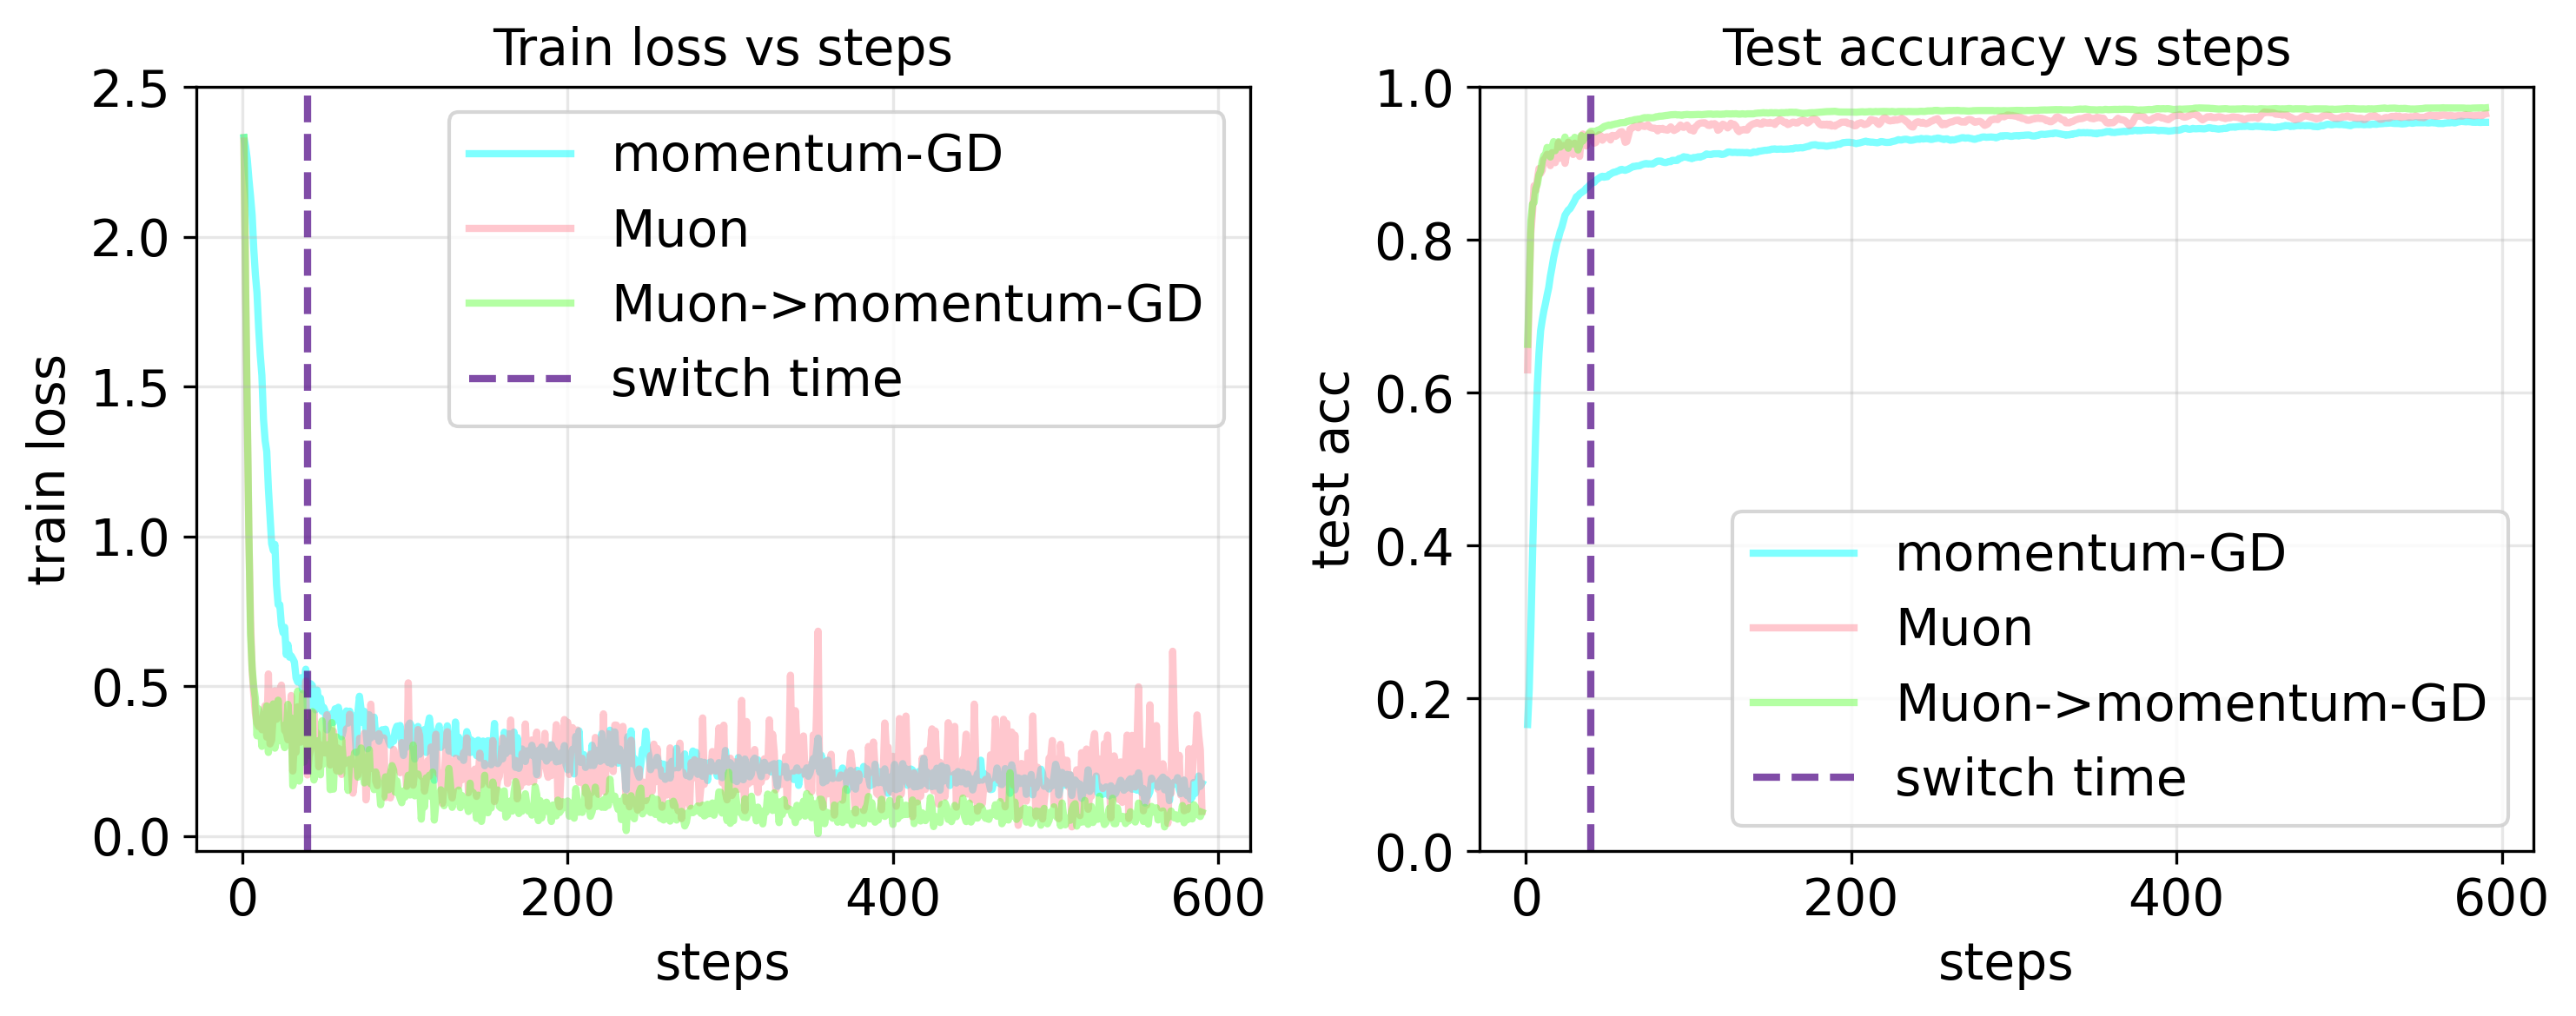

Saved figure to: two_layer_neural_network_case_hybrid1.pdf


In [12]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw=dict(width_ratios=[1.0, 1.0]))

# left: train loss vs steps
ax0.plot(history1["train_step"], history1["train_loss"], 
         linewidth=2.0, color="#00ffff", alpha=0.5, label="momentum-GD", zorder=0)
ax0.plot(history3["train_step"], history3["train_loss"], 
         linewidth=2.0, color="#ff919e", alpha=0.5, label="Muon", zorder=1)
ax0.plot(history4["train_step"], history4["train_loss"], 
         linewidth=2.0, color="#6bff48", alpha=0.5, label="Muon->momentum-GD", zorder=1)
ax0.axvline(args.switch_muon_to_m_gd,  # proposed Muon->momentum-GD switch time
            color='#4B0082', linestyle='--', linewidth=2, alpha=0.7, label="switch time")
ax0.set_title("Train loss vs steps", fontsize=14)
ax0.set_xlabel("steps", fontsize=14)
ax0.set_ylabel("train loss", fontsize=14)
ax0.legend(loc="upper right", frameon=True, fontsize=14)
ax0.set_ylim(-0.05, 2.5)
ax0.tick_params(axis='both', labelsize=14)
ax0.grid(True, alpha=0.3)

# right: test acc vs steps
ax1.plot(history1["test_step"], history1["test_acc"], 
         linewidth=2.0, color="#00ffff", alpha=0.5, label="momentum-GD", zorder=0)
ax1.plot(history3["test_step"], history3["test_acc"], 
         linewidth=2.0, color="#ff919e", alpha=0.5, label="Muon", zorder=1)
ax1.plot(history4["test_step"], history4["test_acc"], 
         linewidth=2.0, color="#6bff48", alpha=0.5, label="Muon->momentum-GD", zorder=1)
ax1.axvline(args.switch_muon_to_m_gd,  # proposed Muon->momentum-GD switch time 
            color='#4B0082', linestyle='--', linewidth=2, alpha=0.7, label="switch time")
ax1.set_title("Test accuracy vs steps", fontsize=14)
ax1.set_xlabel("steps", fontsize=14)
ax1.set_ylabel("test acc", fontsize=14)
ax1.set_ylim(0.0, 1.0)
ax1.legend(loc="lower right", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()
fig.savefig("two_layer_neural_network_case_hybrid1.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: two_layer_neural_network_case_hybrid1.pdf")

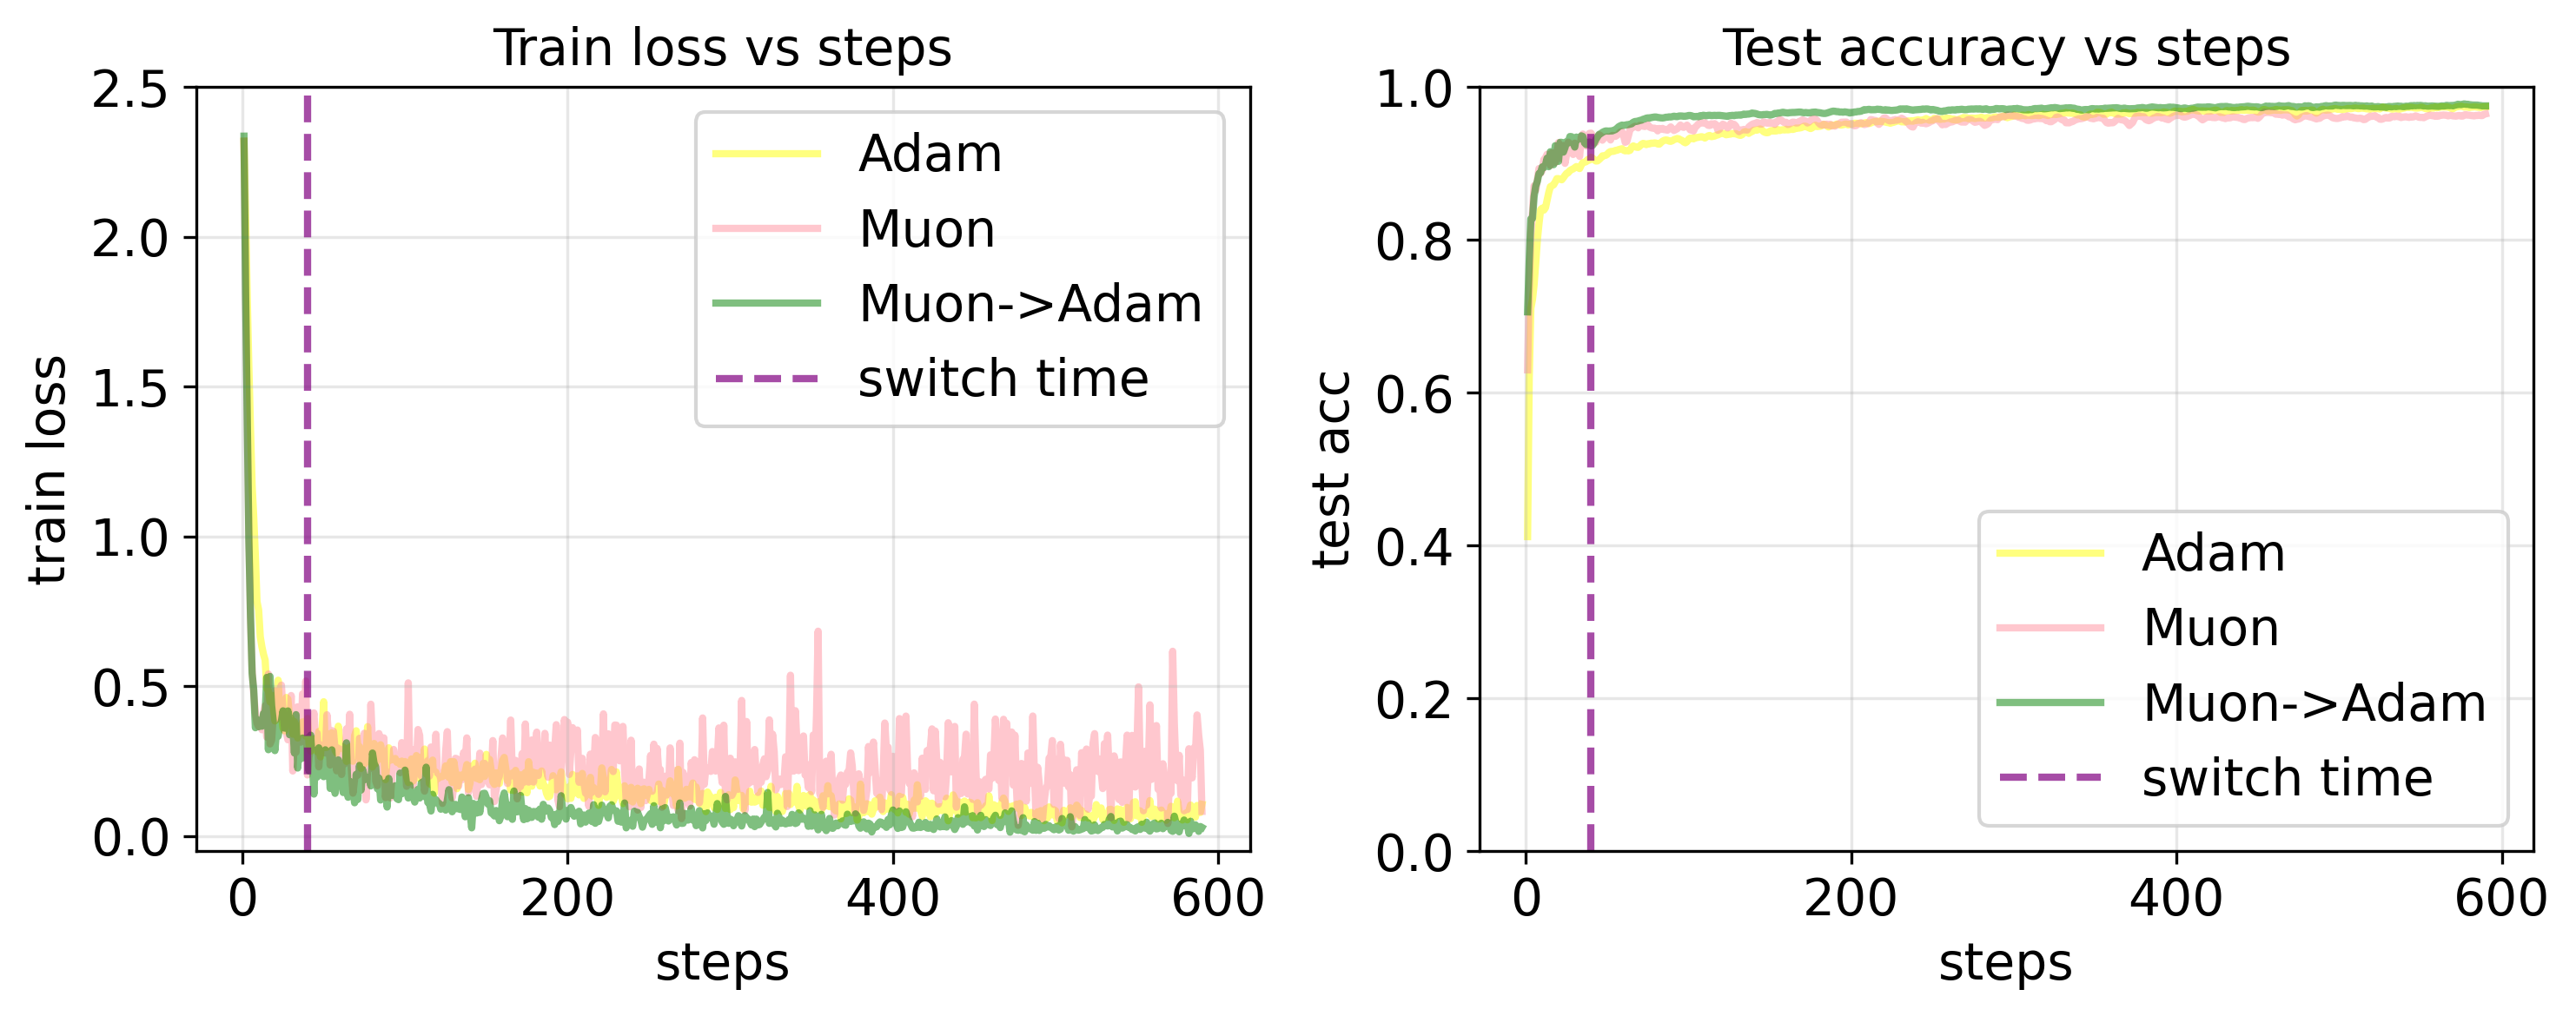

Saved figure to: two_layer_neural_network_case_hybrid2.pdf


In [13]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw=dict(width_ratios=[1.0, 1.0]))

# left: train loss vs steps
ax0.plot(history2["train_step"], history2["train_loss"], 
         linewidth=2.0, color="#ffff00", alpha=0.5, label="Adam", zorder=0)
ax0.plot(history3["train_step"], history3["train_loss"], 
         linewidth=2.0, color="#ff919e", alpha=0.5, label="Muon", zorder=1)
ax0.plot(history5["train_step"], history5["train_loss"], 
         linewidth=2.0, color="#008000", alpha=0.5, label="Muon->Adam", zorder=2)
ax0.axvline(args.switch_muon_to_adam,  # proposed Muon->Adam switch time
            color='#800080', linestyle='--', linewidth=2, alpha=0.7, label="switch time")
ax0.set_title("Train loss vs steps", fontsize=14)
ax0.set_xlabel("steps", fontsize=14)
ax0.set_ylabel("train loss", fontsize=14)
ax0.legend(loc="upper right", frameon=True, fontsize=14)
ax0.set_ylim(-0.05, 2.5)
ax0.tick_params(axis='both', labelsize=14)
ax0.grid(True, alpha=0.3)

# right: test acc vs steps
ax1.plot(history2["test_step"], history2["test_acc"], 
         linewidth=2.0, color="#ffff00", alpha=0.5, label="Adam", zorder=0)
ax1.plot(history3["test_step"], history3["test_acc"], 
         linewidth=2.0, color="#ff919e", alpha=0.5, label="Muon", zorder=1)
ax1.plot(history5["test_step"], history5["test_acc"], 
         linewidth=2.0, color="#008000", alpha=0.5, label="Muon->Adam", zorder=2)
ax1.axvline(args.switch_muon_to_adam,  # proposed Muon->Adam switch time
            color='#800080', linestyle='--', linewidth=2, alpha=0.7, label="switch time")
ax1.set_title("Test accuracy vs steps", fontsize=14)
ax1.set_xlabel("steps", fontsize=14)
ax1.set_ylabel("test acc", fontsize=14)
ax1.set_ylim(0.0, 1.0)
ax1.legend(loc="lower right", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()
fig.savefig("two_layer_neural_network_case_hybrid2.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: two_layer_neural_network_case_hybrid2.pdf")